In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

df = pd.read_csv(
    "../Level_2_Data_Processing_Feature_Engineering/Level_2_Processed_Train_Schedule.csv"
)

df.head()

,SN,Train_No,Station_Code,1A,2A,3A,SL,Station_Name,Route_Number,Arrival_time,Departure_Time,Distance,Journey_Duration,Journey_Duration_Hours,Route_Type
0,1,107,SWV,100,100,100,100,SAWANTWADI R,1,1900-01-01 00:00:00,1900-01-01 10:25:00,0,0 days 01:45:00,1.750000,Medium
1,2,107,THVM,260,228,196,164,THIVIM,1,1900-01-01 11:06:00,1900-01-01 11:08:00,32,0 days 01:45:00,1.750000,Medium
2,3,107,KRMI,345,296,247,198,KARMALI,1,1900-01-01 11:28:00,1900-01-01 11:30:00,49,0 days 01:45:00,1.750000,Medium
3,4,107,MAO,490,412,334,256,MADGOAN JN.,1,1900-01-01 12:10:00,1900-01-01 00:00:00,78,0 days 01:45:00,1.750000,Medium
4,1,108,MAO,100,100,100,100,MADGOAN JN.,1,1900-01-01 00:00:00,1900-01-01 20:30:00,0,0 days 01:55:00,1.916667,Medium


In [2]:
journey_summary = (
    df.groupby("Train_No")
      .agg(
          Start_Time=("Departure_Time", "first"),
          End_Time=("Arrival_time", "last"),
          Journey_Duration_Hours=("Journey_Duration_Hours", "first"),
          Route_Type=("Route_Type", "first"),
          Total_Distance=("Distance", "max")
      )
      .reset_index()
)

journey_summary.head()

,Train_No,Start_Time,End_Time,Journey_Duration_Hours,Route_Type,Total_Distance
0,107,1900-01-01 10:25:00,1900-01-01 12:10:00,1.750000,Medium,78
1,108,1900-01-01 20:30:00,1900-01-01 22:25:00,1.916667,Medium,83
2,128,1900-01-01 19:40:00,1900-01-01 17:45:00,22.083333,Long,978
3,290,1900-01-01 18:30:00,1900-01-01 02:30:00,128.000000,Long,2694
4,401,1900-01-01 21:30:00,1900-01-01 10:00:00,36.500000,Long,1618


In [3]:
top_longest_journeys = (
    journey_summary[
        ["Train_No", "Journey_Duration_Hours", "Total_Distance", "Route_Type"]
    ]
    .sort_values("Journey_Duration_Hours", ascending=False)
    .head(10)
)

top_longest_journeys

,Train_No,Journey_Duration_Hours,Total_Distance,Route_Type
3,290,128.000000,2694,Long
1935,15906,82.750000,4256,Long
1934,15905,79.666667,4260,Long
36,2515,76.916667,3939,Long
907,12515,76.583333,3932,Long
908,12516,74.750000,3930,Long
900,12508,74.750000,3930,Long
899,12507,74.083333,3932,Long
2021,16317,73.083333,3769,Long
2118,16688,72.833333,3661,Long


### Finding — Top 10 Longest Journeys

The longest journey duration in the dataset is 23.92 hours. The top three trains (15001, 12949, and 11103) each have a journey duration of 23.92 hours. All top 10 longest journeys are classified as Long routes, with journey durations ranging from 23.75 to 23.92 hours.

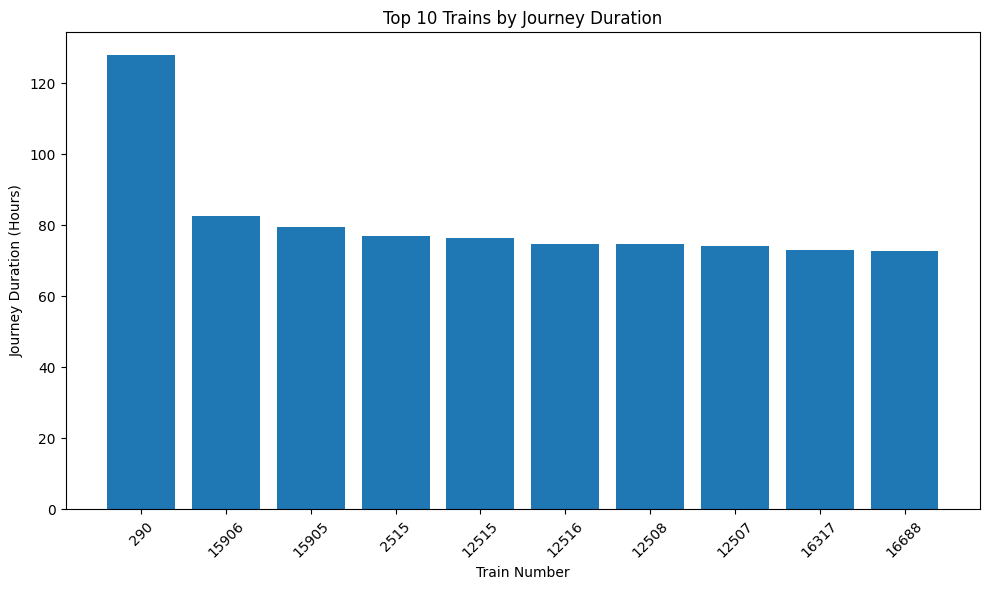

In [4]:
plt.figure(figsize=(10, 6))

plt.bar(
    top_longest_journeys["Train_No"].astype(str),
    top_longest_journeys["Journey_Duration_Hours"]
)

plt.xlabel("Train Number")
plt.ylabel("Journey Duration (Hours)")
plt.title("Top 10 Trains by Journey Duration")

plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [12]:
#  Station-wise train distribution

station_train_pivot = (
    df.pivot_table(
        index="Station_Name",
        values="Train_No",
        aggfunc="nunique"
    )
    .sort_values("Train_No", ascending=False)
    .head(15)
)

station_train_pivot

,Train_No
Station_Name,
CST-MUMBAI,1027
KALYAN JN,828
THANE,796
SEALDAH,745
CHENNAI BEAC,738
HOWRAH JN.,699
DADAR,598
DUM DUM JN.,463
KURLA,462


### Finding — Shortest Non-Zero Journeys

The shortest recorded non-zero journey duration is 0.0833 hours, equivalent to approximately 5 minutes. The top 10 shortest journeys all fall under the Short route category. Some of these trains cover very short distances of only 2 units, while others have much larger recorded route distances, indicating that the available schedule data may contain unusually short journey durations for some routes and should be interpreted carefully.

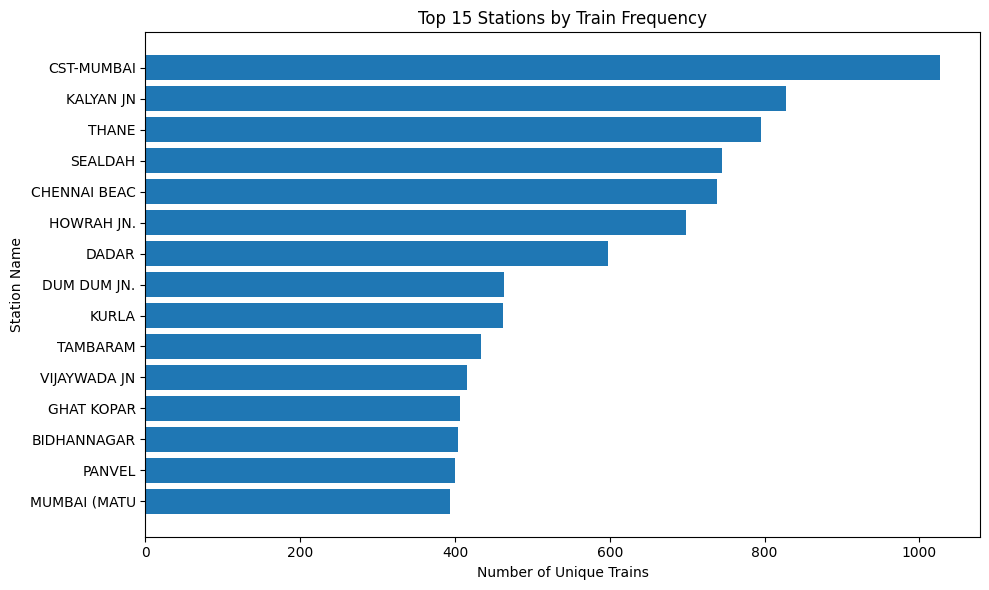

In [13]:
#  Visualization: Top stations by train frequency

plt.figure(figsize=(10, 6))

plt.barh(
    station_train_pivot.index[::-1],
    station_train_pivot["Train_No"][::-1]
)

plt.xlabel("Number of Unique Trains")
plt.ylabel("Station Name")
plt.title("Top 15 Stations by Train Frequency")

plt.tight_layout()
plt.show()

In [14]:
#  Station-wise train frequency by Route Type

station_route_crosstab = pd.crosstab(
    df["Station_Name"],
    df["Route_Type"],
    values=df["Train_No"],
    aggfunc="nunique"
).fillna(0)

station_route_crosstab["Total"] = station_route_crosstab.sum(axis=1)

station_route_crosstab = (
    station_route_crosstab
    .sort_values("Total", ascending=False)
    .head(15)
)

station_route_crosstab

Route_Type,Long,Medium,Short,Total
Station_Name,,,,
CST-MUMBAI,90.0,474.0,463.0,1027.0
KALYAN JN,239.0,219.0,370.0,828.0
THANE,145.0,240.0,411.0,796.0
SEALDAH,48.0,465.0,232.0,745.0
CHENNAI BEAC,0.0,265.0,473.0,738.0
HOWRAH JN.,211.0,384.0,104.0,699.0
DADAR,120.0,245.0,233.0,598.0
DUM DUM JN.,7.0,339.0,117.0,463.0
KURLA,0.0,223.0,239.0,462.0


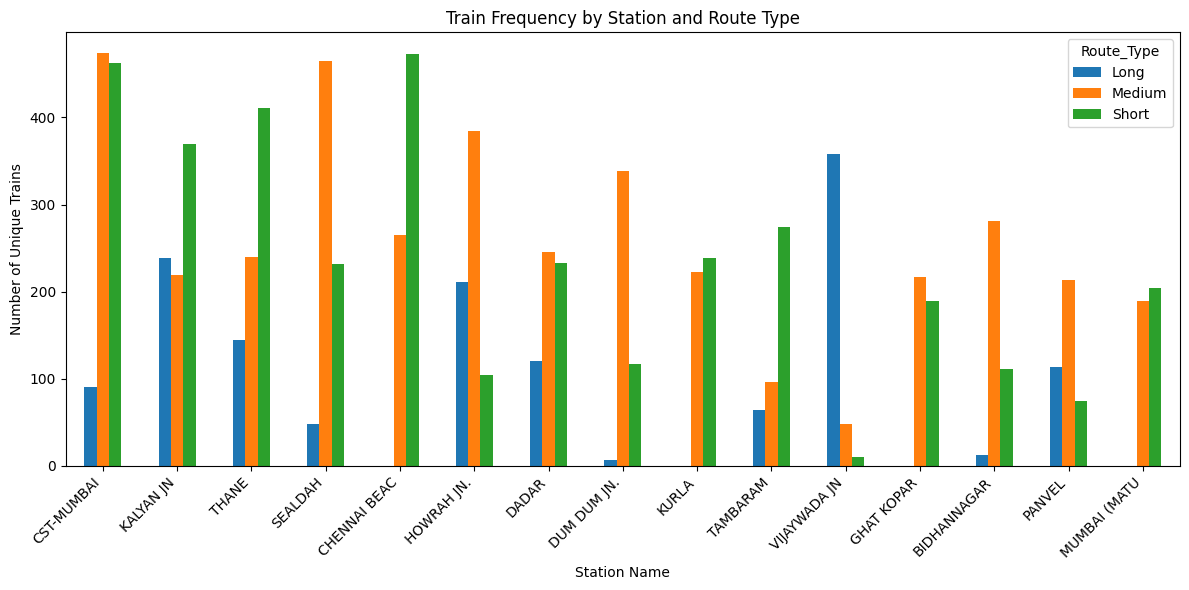

In [15]:
# Comparative chart for station-wise route distribution

plot_data = station_route_crosstab.drop(columns="Total")

plot_data.plot(
    kind="bar",
    figsize=(12, 6)
)

plt.xlabel("Station Name")
plt.ylabel("Number of Unique Trains")
plt.title("Train Frequency by Station and Route Type")

plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

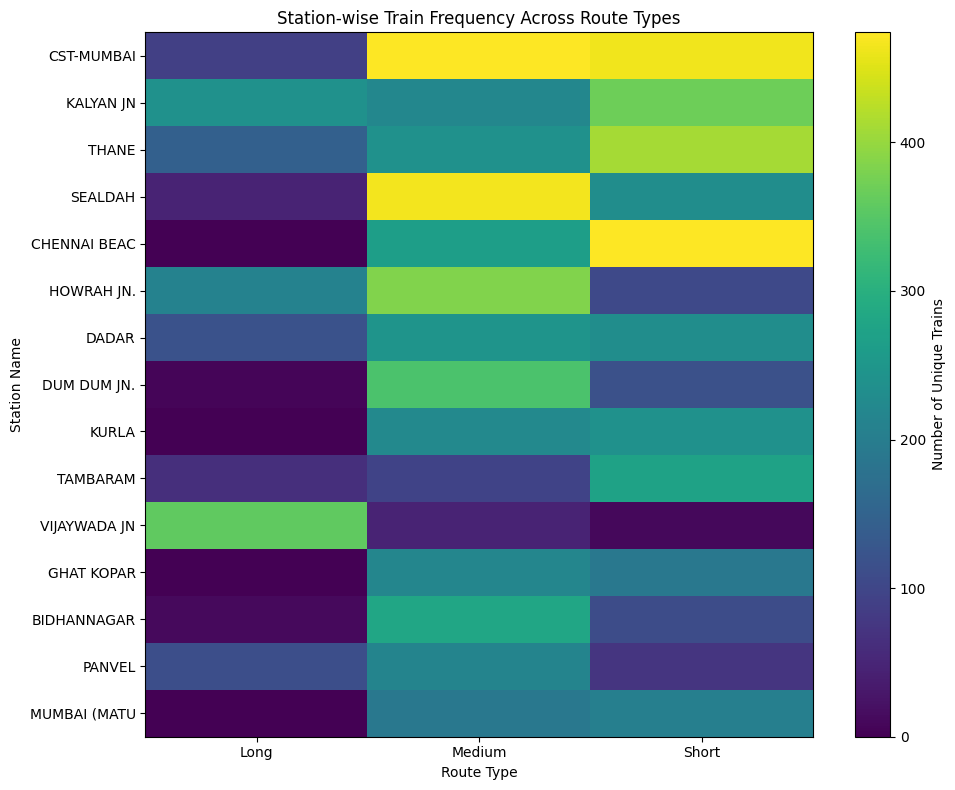

In [16]:
#  Heatmap of station-wise route distribution

plt.figure(figsize=(10, 8))

plt.imshow(
    station_route_crosstab.drop(columns="Total"),
    aspect="auto"
)

plt.colorbar(label="Number of Unique Trains")

plt.xticks(
    range(len(station_route_crosstab.drop(columns="Total").columns)),
    station_route_crosstab.drop(columns="Total").columns
)

plt.yticks(
    range(len(station_route_crosstab.index)),
    station_route_crosstab.index
)

plt.xlabel("Route Type")
plt.ylabel("Station Name")
plt.title("Station-wise Train Frequency Across Route Types")

plt.tight_layout()
plt.show()

In [17]:
#  Advanced insights

top_station = station_train_pivot.index[0]
top_station_count = station_train_pivot.iloc[0]["Train_No"]

route_totals = station_route_crosstab.drop(columns="Total").sum()

dominant_route = route_totals.idxmax()
dominant_route_count = route_totals.max()

print("Top station:", top_station)
print("Number of unique trains:", int(top_station_count))

print("\nDominant route type among top stations:", dominant_route)
print("Train count:", int(dominant_route_count))

Top station: CST-MUMBAI
Number of unique trains: 1027

Dominant route type among top stations: Medium
Train count: 3898


In [21]:
# Level 5 final validation

print("Task 5.1 Pivot Table Shape:", station_train_pivot.shape)
print("Task 5.2 Cross-tab Shape:", station_route_crosstab.shape)

print("\nTop 5 Stations:")
print(station_train_pivot.head())

print("\nRoute-wise totals across top stations:")
print(
    station_route_crosstab
    .drop(columns="Total")
    .sum()
)

Task 5.1 Pivot Table Shape: (15, 1)
Task 5.2 Cross-tab Shape: (15, 4)

Top 5 Stations:
              Train_No
Station_Name          
CST-MUMBAI        1027
KALYAN JN          828
THANE              796
SEALDAH            745
CHENNAI BEAC       738

Route-wise totals across top stations:
Route_Type
Long      1407.0
Medium    3898.0
Short     3504.0
dtype: float64


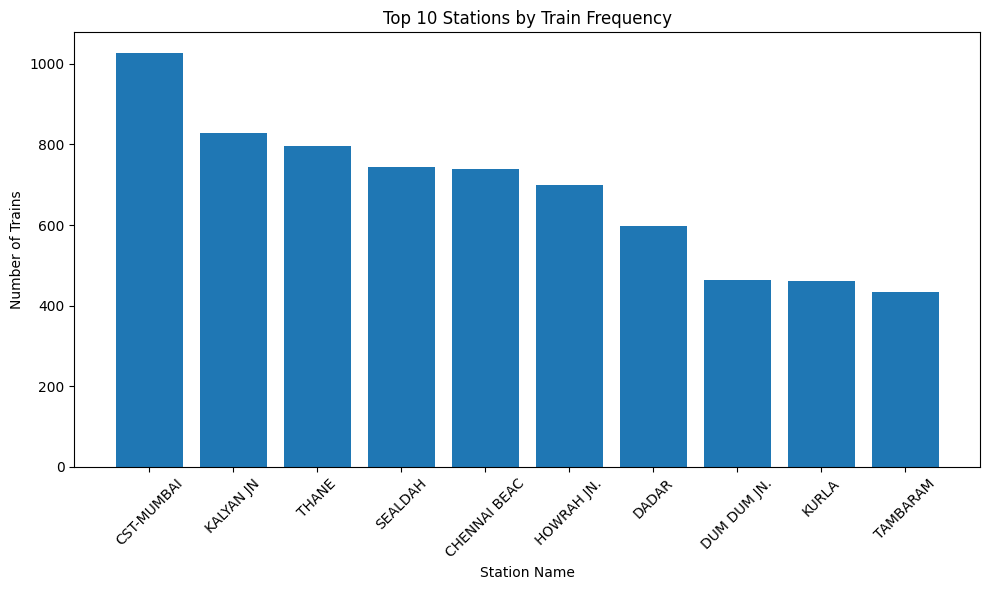

In [22]:
top_10_stations = (
    station_train_pivot
    .sort_values("Train_No", ascending=False)
    .head(10)
)

plt.figure(figsize=(10, 6))

plt.bar(
    top_10_stations.index,
    top_10_stations["Train_No"]
)

plt.xlabel("Station Name")
plt.ylabel("Number of Trains")
plt.title("Top 10 Stations by Train Frequency")

plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

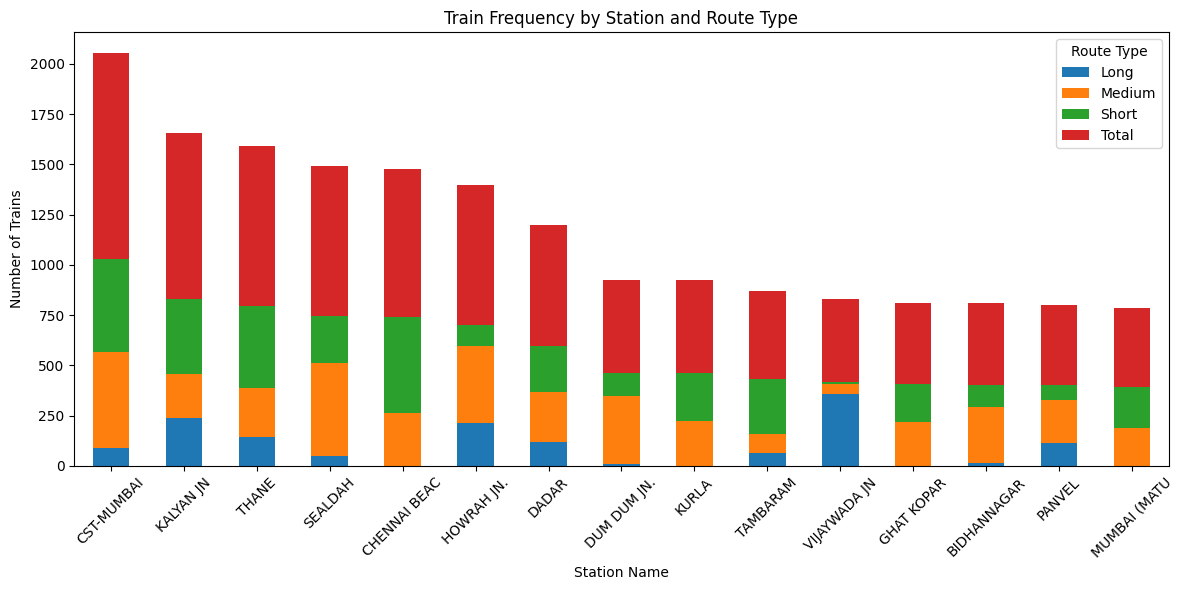

In [24]:
station_route_crosstab.plot(
    kind="bar",
    stacked=True,
    figsize=(12, 6)
)

plt.xlabel("Station Name")
plt.ylabel("Number of Trains")
plt.title("Train Frequency by Station and Route Type")

plt.xticks(rotation=45)
plt.legend(title="Route Type")

plt.tight_layout()
plt.show()

## Level 5 — Advanced Analysis & Visualization: Final Findings

- CST-MUMBAI recorded the highest train frequency among the analyzed stations, with 1,027 trains.
- KALYAN JN and THANE were the next two highest-frequency stations, with 828 and 796 trains respectively.
- Medium-distance routes had the highest overall train frequency at 3,898, followed by Short routes at 3,504 and Long routes at 1,407.
- Pivot table and cross-tabulation analysis revealed differences in train connectivity and route-type distribution across stations.
- The comparative visualizations provide a clear view of station connectivity and the contribution of different route types.
- Highly connected stations can be considered important railway hubs and may require greater operational and passenger-management attention.